kernel density estimation, k-fold cross validation, kmeans clustering, Gaussian Mixture Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [3]:
print(names)
print(len(data))
print(len(names))
print(len(data[0]))

['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']
15
15
9165


In [4]:
T90 = np.array(data[6], dtype=float)
T90 = np.array([x for x in T90 if x>0])
print(np.min(T90))
print(np.max(T90))

0.008
2100.0


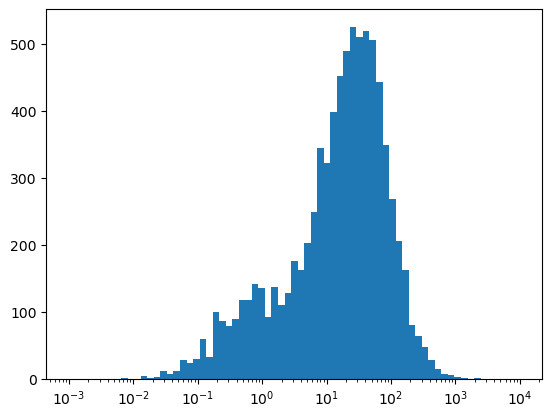

In [5]:
plt.hist(T90, bins=np.logspace(-3, 4, 70));
plt.xscale("log")

In [6]:
fluence = np.array(data[9], dtype=float)
fluence = [x for x in fluence if x>0]
print(np.min(fluence))
print(np.max(fluence))

1.9317e-10
0.038836


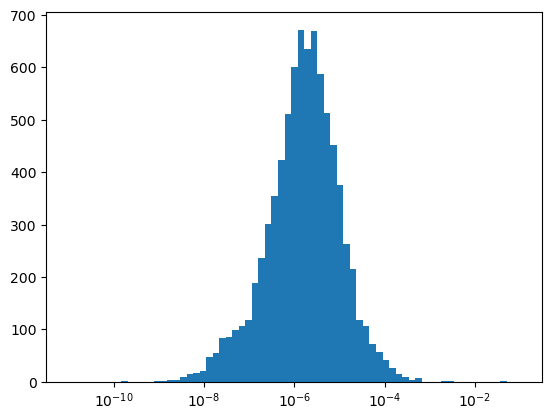

In [7]:
plt.hist(fluence, bins=np.logspace(-11, -1, 70))
plt.xscale("log")

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

bwrange = np.linspace(0.01,1.0, 40)                                         #Test 30 bandwidths from 0.1 to 1.0
print(bwrange)
K = 5                                                                       #Do 5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K)         #Try each bandwidth with K-folds
grid.fit(np.log10(T90[:, None]))                                            #Fit the histogram data that we started the lecture with.
h_opt = grid.best_params_['bandwidth']
print(h_opt)

#1 minuto e 10 secondi

[0.01       0.03538462 0.06076923 0.08615385 0.11153846 0.13692308
 0.16230769 0.18769231 0.21307692 0.23846154 0.26384615 0.28923077
 0.31461538 0.34       0.36538462 0.39076923 0.41615385 0.44153846
 0.46692308 0.49230769 0.51769231 0.54307692 0.56846154 0.59384615
 0.61923077 0.64461538 0.67       0.69538462 0.72076923 0.74615385
 0.77153846 0.79692308 0.82230769 0.84769231 0.87307692 0.89846154
 0.92384615 0.94923077 0.97461538 1.        ]
0.11153846153846153


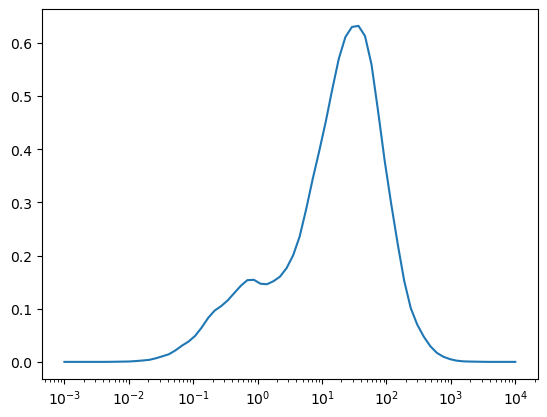

In [9]:
xgrid =np.logspace(-3, 4, 70)

def kde_sklearn(data, bandwidth = 1.0):
    kde_skl = KernelDensity(bandwidth = bandwidth)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(np.log10(xgrid[:, np.newaxis]))
    return np.exp(log_pdf)

pdf = kde_sklearn(np.log10(T90), bandwidth=h_opt)
plt.plot(xgrid, pdf)
plt.xscale("log")

[-1.01772877  1.55126697 -0.18309616 ...  0.49637605  2.31926433
  0.71466499]


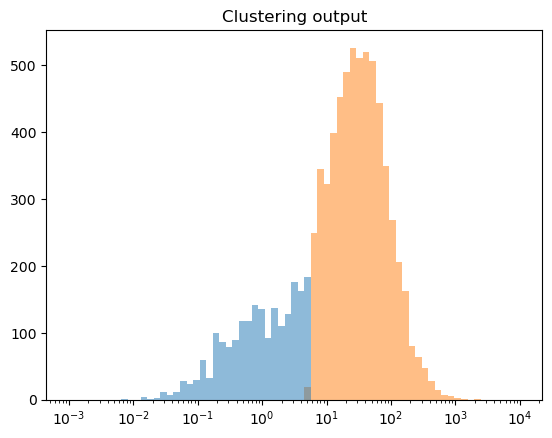

In [10]:
from sklearn.cluster import KMeans
from sklearn import preprocessing

X = np.log10(T90)[:, np.newaxis]

clf = KMeans(n_clusters=2, n_init='auto')   #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_              #location of the clusters
labels = clf.predict(X)                     #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
print(X[:,0])

for i in range(len(np.unique(labels))):
    plt.hist(10**X[:,0][labels==i], bins=xgrid, color=colors[i], alpha=0.5)
    #plt.scatter(10**X[:,0][labels==i], 10**X[:,0][labels==i], color=colors[i], alpha=0.5)

# To get some information on these try:
# KMeans?
# help(clf)
plt.title('Clustering output');
plt.xscale("log")

In [11]:
print(centers[0])

[1.5205527]


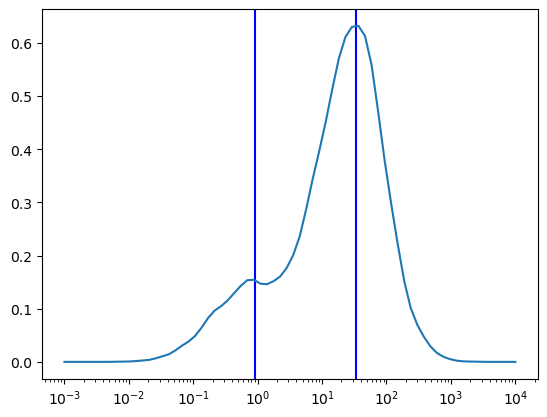

In [12]:

plt.axvline(x = 10**centers[1], color = 'b', label = 'center1')
plt.axvline(x = 10**centers[0], color = 'b', label = 'center2')
plt.plot(xgrid, pdf)
plt.xscale("log")

In [13]:
from sklearn.mixture import GaussianMixture


Ns = np.arange(1, 5)        #just to make sure
models=[GaussianMixture(N).fit(np.log10(T90)[:, np.newaxis]) for N in Ns]

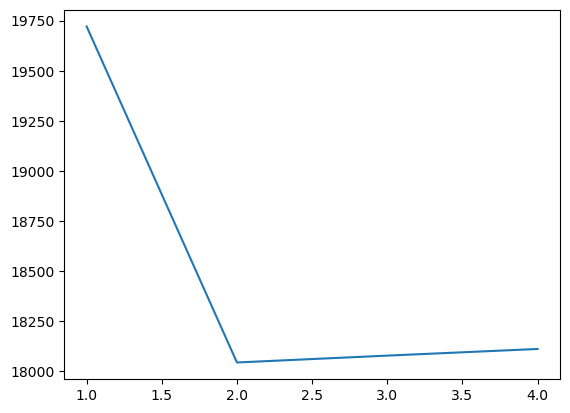

In [14]:
AIC = [m.aic(np.log10(T90)[:, np.newaxis]) for m in models]
plt.plot(Ns, AIC)

In [15]:
print(10**models[1].means_)
print(10**centers)

[[30.59488564]
 [ 0.97132971]]
[[33.15527985]
 [ 0.91859396]]
